# Fraud Detection — Exploratory Data Analysis

## Business Context

Every card transaction is a real-time decision: **approve or block**.  
A fraud detection system must balance two competing business costs:

| Outcome | What it means |
|---|---|
| **True Positive** (fraud caught) | Financial loss prevented; customer protected |
| **False Positive** (legit tx blocked) | Customer frustrated; potential churn; reputational damage |
| **True Negative** (legit tx approved) | Normal business |
| **False Negative** (fraud missed) | Direct financial loss; regulatory exposure; customer harm |

This notebook characterises the dataset to understand:
- How severe the class imbalance is (and why it makes **accuracy a misleading metric**)
- Transaction amount and time patterns that differ between fraud and legitimate activity
- Feature distributions that will inform preprocessing choices in modelling

> **Data note:** The 28 `V1–V28` features are the result of PCA applied to the raw transaction features to protect cardholder privacy. `Time` is seconds since the first transaction in the dataset; `Amount` is the transaction value in the original currency.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
FRAUD_COLOR, LEGIT_COLOR = '#e74c3c', '#2ecc71'

DB_PATH = Path('../data/fraud_detection.db')
conn = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH)

Connected to ..\data\fraud_detection.db


## 1. Class Imbalance — Why Accuracy Is Misleading

In financial crime detection, fraudulent transactions are rare by design — fraudsters operate under the radar to avoid detection.  
This creates a heavily **imbalanced dataset** where a naive model that predicts "legitimate" for every transaction would achieve >99% accuracy, yet catch **zero fraud**.

The query below gives us the ground truth on how imbalanced our dataset is.

In [2]:
class_counts = pd.read_sql_query("""
    SELECT
        is_fraud,
        COUNT(*) AS count
    FROM transactions
    GROUP BY is_fraud
    ORDER BY is_fraud
""", conn)

total = class_counts['count'].sum()
class_counts['pct'] = (class_counts['count'] / total * 100).round(4)
class_counts['label'] = class_counts['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})
print(class_counts[['label', 'count', 'pct']].to_string(index=False))

     label  count     pct
Legitimate 284315 99.8273
     Fraud    492  0.1727


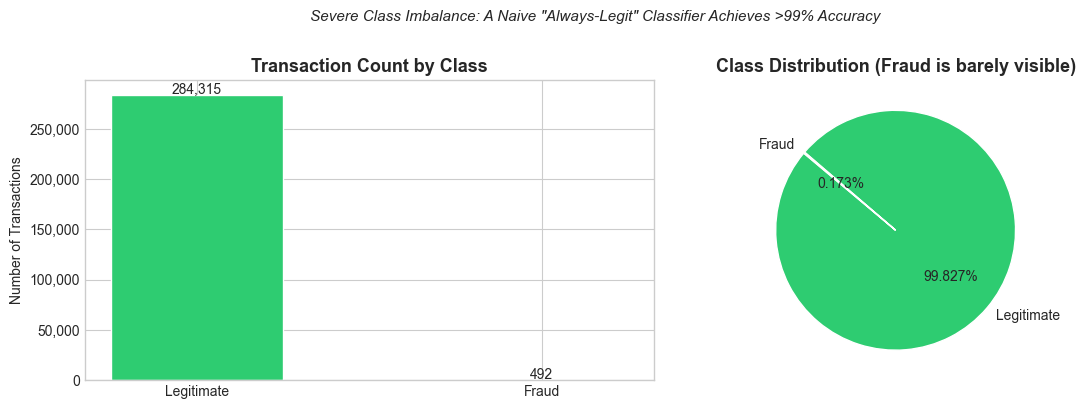


Imbalance ratio: 1 fraud per every 579 transactions


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(class_counts['label'], class_counts['count'],
                   color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white', width=0.5)
for bar, val in zip(bars, class_counts['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', fontsize=10)
axes[0].set_title('Transaction Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie chart
axes[1].pie(class_counts['count'], labels=class_counts['label'],
            colors=[LEGIT_COLOR, FRAUD_COLOR], autopct='%1.3f%%',
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Distribution (Fraud is barely visible)', fontsize=13, fontweight='bold')

plt.suptitle('Severe Class Imbalance: A Naive "Always-Legit" Classifier Achieves >99% Accuracy',
             fontsize=11, style='italic', y=1.01)
plt.tight_layout()
plt.show()

fraud_pct = class_counts.loc[class_counts['is_fraud']==1, 'pct'].values[0]
print(f'\nImbalance ratio: 1 fraud per every {round(100/fraud_pct):,} transactions')

**Key takeaway:** With only ~0.17% of transactions being fraudulent, a model that blindly approves everything achieves 99.83% accuracy while providing **zero business value**.

This is why fraud detection teams use **Precision-Recall AUC** as the primary metric — it focuses on how well the model performs on the rare positive (fraud) class:
- **Precision** = of all transactions the model flags as fraud, how many actually are? (cost of false alarms → blocked customers)
- **Recall** = of all actual fraud cases, how many did we catch? (cost of misses → financial losses)

## 2. Transaction Amount Analysis

Fraudsters often probe with small transactions to verify a stolen card before making larger purchases — or conversely, maximise the stolen value before the card is blocked. Examining amount distributions can reveal these behavioural signatures.

In [4]:
amount_stats = pd.read_sql_query("""
    SELECT
        CASE is_fraud WHEN 0 THEN 'Legitimate' ELSE 'Fraud' END AS transaction_type,
        COUNT(*)                          AS count,
        ROUND(AVG(Amount), 2)             AS mean_amount,
        ROUND(MIN(Amount), 2)             AS min_amount,
        ROUND(MAX(Amount), 2)             AS max_amount,
        ROUND(SUM(Amount), 2)             AS total_exposure
    FROM transactions
    GROUP BY is_fraud
    ORDER BY is_fraud
""", conn)

print(amount_stats.to_string(index=False))

transaction_type  count  mean_amount  min_amount  max_amount  total_exposure
      Legitimate 284315        88.29         0.0    25691.16     25102462.04
           Fraud    492       122.21         0.0     2125.87        60127.97


C:\Users\toyin\AppData\Local\Temp\ipykernel_30892\4026065675.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([legit_amounts, fraud_amounts], labels=['Legitimate', 'Fraud'],


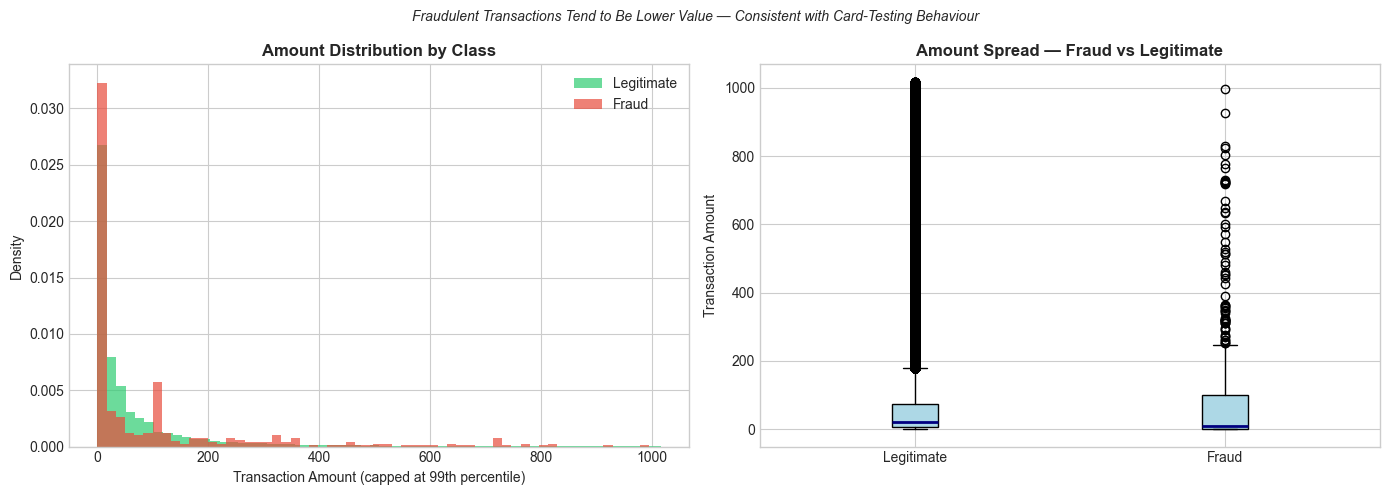

In [5]:
# Load amounts — cap at 99th percentile in pandas (SQLite lacks PERCENTILE_CONT)
all_amounts = pd.read_sql_query("SELECT Amount, is_fraud FROM transactions", conn)
cap_99 = all_amounts['Amount'].quantile(0.99)
amounts = all_amounts[all_amounts['Amount'] <= cap_99]

fraud_amounts = amounts[amounts['is_fraud'] == 1]['Amount']
legit_amounts = amounts[amounts['is_fraud'] == 0]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(legit_amounts, bins=60, alpha=0.7, color=LEGIT_COLOR, label='Legitimate', density=True)
axes[0].hist(fraud_amounts, bins=60, alpha=0.7, color=FRAUD_COLOR, label='Fraud', density=True)
axes[0].set_xlabel('Transaction Amount (capped at 99th percentile)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution by Class', fontweight='bold')
axes[0].legend()

axes[1].boxplot([legit_amounts, fraud_amounts], labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_ylabel('Transaction Amount')
axes[1].set_title('Amount Spread — Fraud vs Legitimate', fontweight='bold')

plt.suptitle('Fraudulent Transactions Tend to Be Lower Value — Consistent with Card-Testing Behaviour',
             fontsize=10, style='italic')
plt.tight_layout()
plt.show()

## 3. Temporal Patterns

Fraud activity often clusters at unusual hours — late night when cardholders are less likely to notice immediate alerts, or during weekends when fraud operations teams may be understaffed. Examining the time dimension can uncover these patterns.

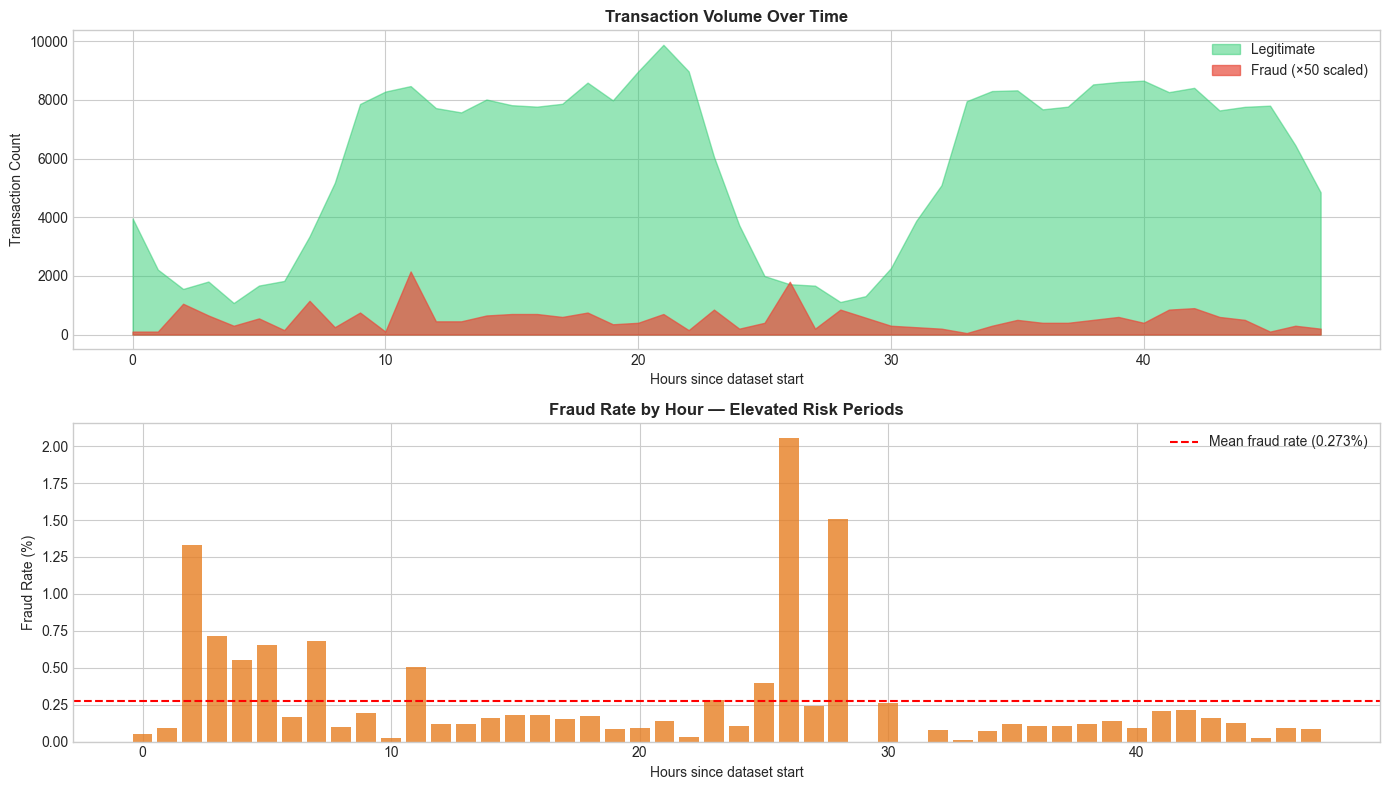

In [6]:
# Bin Time into approximate hours (dataset covers ~48 hours)
time_data = pd.read_sql_query("""
    SELECT
        CAST(Time / 3600 AS INTEGER) AS hour_bin,
        is_fraud,
        COUNT(*) AS count
    FROM transactions
    GROUP BY hour_bin, is_fraud
    ORDER BY hour_bin, is_fraud
""", conn)

fraud_time = time_data[time_data['is_fraud'] == 1].set_index('hour_bin')['count']
legit_time = time_data[time_data['is_fraud'] == 0].set_index('hour_bin')['count']

# Fraud rate per hour bin
fraud_rate = pd.read_sql_query("""
    SELECT
        CAST(Time / 3600 AS INTEGER)          AS hour_bin,
        ROUND(AVG(is_fraud) * 100, 4)         AS fraud_rate_pct,
        COUNT(*)                              AS total_txns
    FROM transactions
    GROUP BY hour_bin
    ORDER BY hour_bin
""", conn)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].fill_between(legit_time.index, legit_time.values, alpha=0.5, color=LEGIT_COLOR, label='Legitimate')
axes[0].fill_between(fraud_time.index, fraud_time.values * 50, alpha=0.7, color=FRAUD_COLOR,
                     label='Fraud (×50 scaled)')
axes[0].set_xlabel('Hours since dataset start')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Transaction Volume Over Time', fontweight='bold')
axes[0].legend()

axes[1].bar(fraud_rate['hour_bin'], fraud_rate['fraud_rate_pct'], color='#e67e22', alpha=0.8)
axes[1].axhline(fraud_rate['fraud_rate_pct'].mean(), color='red', linestyle='--',
                label=f"Mean fraud rate ({fraud_rate['fraud_rate_pct'].mean():.3f}%)")
axes[1].set_xlabel('Hours since dataset start')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Hour — Elevated Risk Periods', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Feature Distribution Analysis

The V1–V28 features are PCA components derived from raw transaction attributes (merchant category, geolocation, device fingerprint, etc.). While we cannot interpret them directly, comparing their distributions between fraud and legitimate transactions tells us **which components carry the most discriminative signal** — essentially, which latent transaction characteristics differ most between fraud and legitimate activity.

Features with high separation between classes will be most valuable to our classifiers.

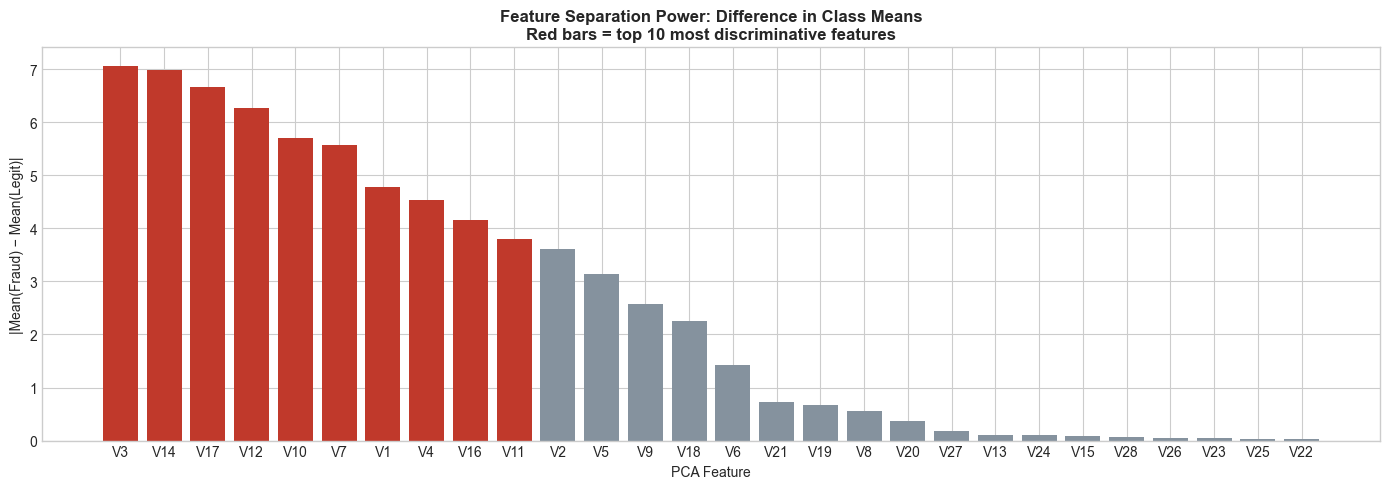

Top 5 most discriminative features:
V3     7.064008
V14    6.990199
V17    6.661150
V12    6.273481
V10    5.704184


In [7]:
# Load a sample for plotting (all fraud + stratified legit sample)
fraud_df = pd.read_sql_query("""
    SELECT * FROM transactions WHERE is_fraud = 1
""", conn)

legit_sample = pd.read_sql_query("""
    SELECT * FROM transactions
    WHERE is_fraud = 0
    ORDER BY RANDOM()
    LIMIT 5000
""", conn)

plot_df = pd.concat([fraud_df, legit_sample], ignore_index=True)

v_features = [f'V{i}' for i in range(1, 29)]

# Compute mean absolute difference between classes for each feature
means = plot_df.groupby('is_fraud')[v_features].mean()
separation = (means.loc[1] - means.loc[0]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(separation.index, separation.values,
              color=['#c0392b' if v in separation.head(10).index else '#85929e'
                     for v in separation.index])
ax.set_xlabel('PCA Feature')
ax.set_ylabel('|Mean(Fraud) − Mean(Legit)|')
ax.set_title('Feature Separation Power: Difference in Class Means\n'
             'Red bars = top 10 most discriminative features', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 most discriminative features:')
print(separation.head(5).to_string())

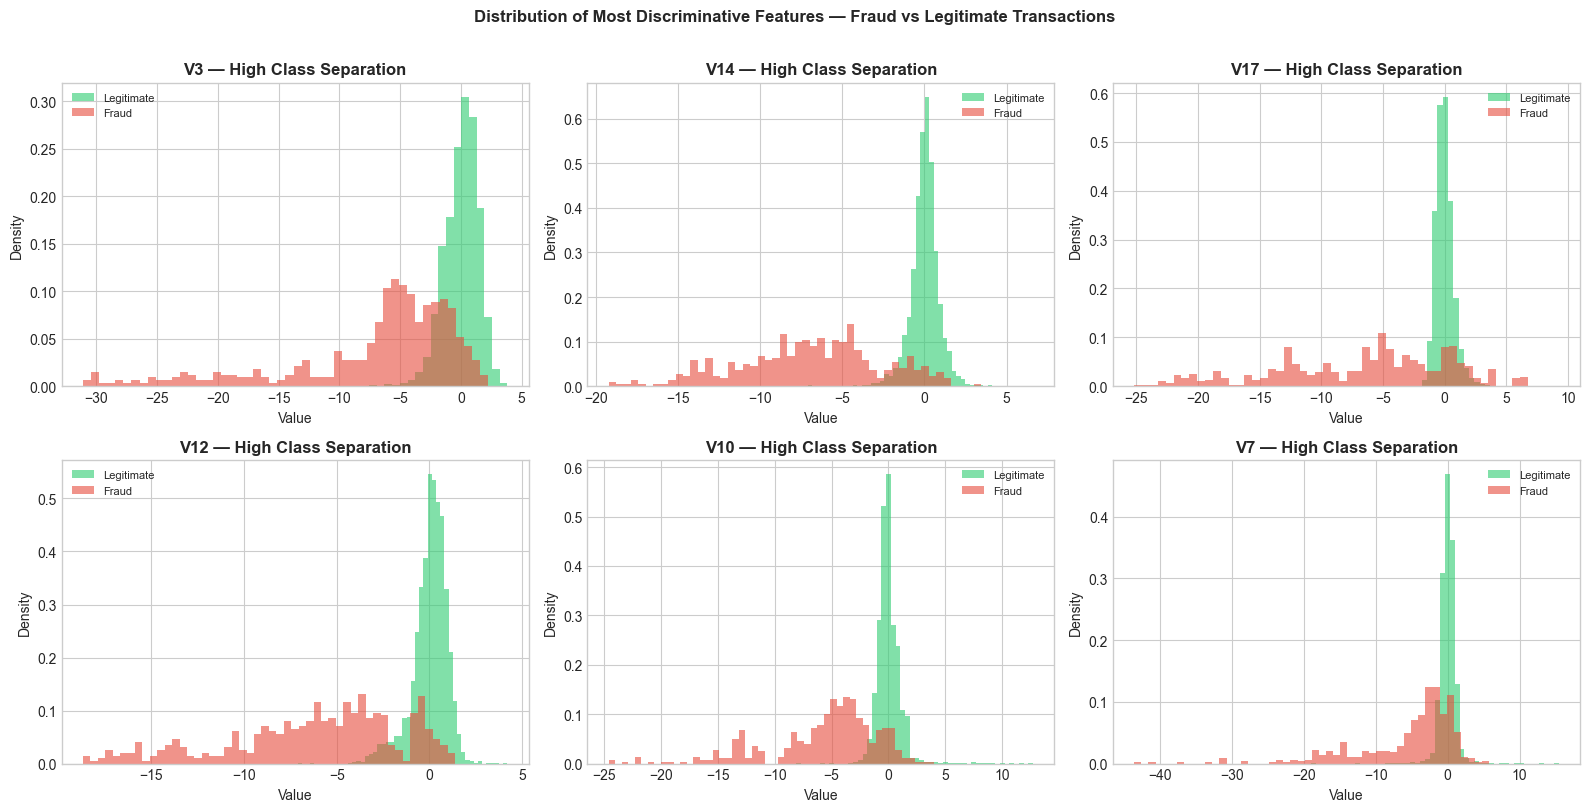

In [8]:
# Distribution plots for top 6 features
top_features = separation.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    fraud_vals = plot_df[plot_df['is_fraud'] == 1][feat]
    legit_vals = plot_df[plot_df['is_fraud'] == 0][feat]
    ax.hist(legit_vals, bins=50, alpha=0.6, color=LEGIT_COLOR,
            density=True, label='Legitimate')
    ax.hist(fraud_vals, bins=50, alpha=0.6, color=FRAUD_COLOR,
            density=True, label='Fraud')
    ax.set_title(f'{feat} — High Class Separation', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Most Discriminative Features — Fraud vs Legitimate Transactions',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

Understanding how features relate to the fraud label and to each other helps us:
1. Identify which features are most predictive of fraud
2. Detect multicollinearity that could inflate variance in linear models
3. Inform feature selection decisions

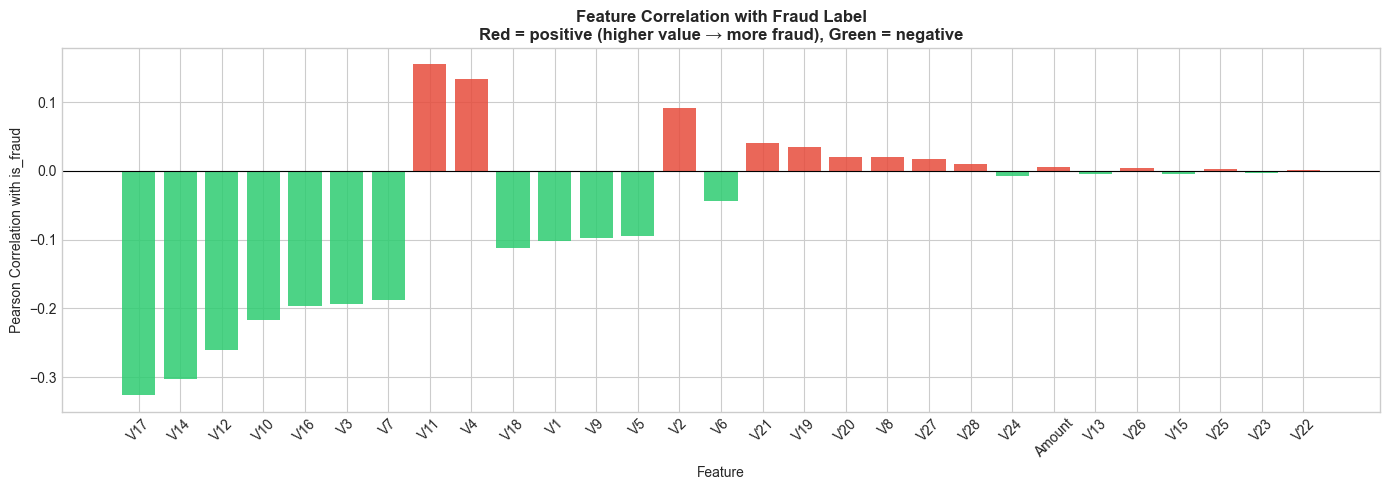

In [9]:
full_df = pd.read_sql_query("SELECT * FROM transactions", conn)

# Correlation of each feature with fraud label
corr_with_fraud = full_df.drop(columns=['Time']).corrwith(
    full_df['is_fraud']
).drop('is_fraud').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = [FRAUD_COLOR if v > 0 else LEGIT_COLOR for v in corr_with_fraud.values]
ax.bar(corr_with_fraud.index, corr_with_fraud.values, color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Feature')
ax.set_ylabel('Pearson Correlation with is_fraud')
ax.set_title('Feature Correlation with Fraud Label\n'
             'Red = positive (higher value → more fraud), Green = negative',
             fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. EDA Summary & Modelling Implications

| Finding | Modelling Implication |
|---|---|
| **0.17% fraud rate** | Accuracy is meaningless; use Precision-Recall AUC. Apply SMOTE or class weights |
| **Fraud amounts skew lower** | Include `Amount` as a feature; consider log-transforming |
| **Temporal clustering** | Time-of-day features could add signal; monitor for concept drift in production |
| **V1, V3, V4, V10, V12, V14 highly discriminative** | These will likely dominate feature importance — useful for SHAP explanations |
| **PCA features are uncorrelated by construction** | Low multicollinearity risk; suits logistic regression well |

**Next step:** Proceed to `02_modeling.ipynb` to train and evaluate classifiers.

In [10]:
conn.close()